In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [2]:
# 데이터 로드
df = pd.read_csv('../data/creditcard.csv')


In [ ]:

# 기본 정보
print(df.shape)
print(df.info())
print(df.isnull().sum())

# 클래스 분포 확인 (핵심!)
print(df['Class'].value_counts())
print(f"사기 비율: {df['Class'].sum() / len(df) * 100:.3f}%")



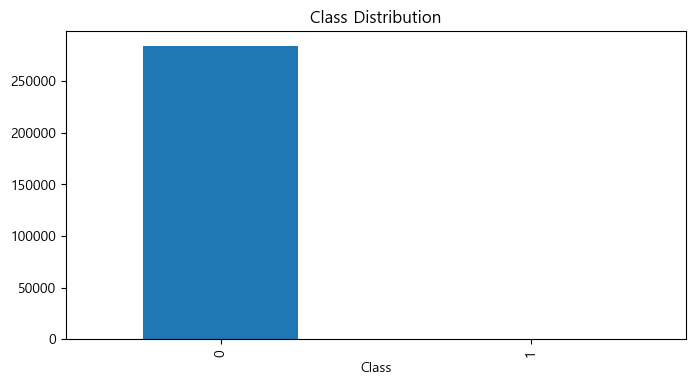

In [ ]:
# 시각화
plt.figure(figsize=(8, 4))
df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')

# 막대 위에 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.show()

In [ ]:
# 2. Data전처리
# Amount와 Time 스케일링 (V1-V28은 이미 PCA 처리됨)
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# 불필요한 컬럼 제거
df_processed = df.drop(['Amount', 'Time'], axis=1)

# 특성과 타겟 분리
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# 학습/테스트 분할 (stratify 중요!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=23, stratify=y
)

In [6]:
# 3. 클래스 불균형 처리 방법
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# 방법 1: SMOTE (오버샘플링)
smote = SMOTE(random_state=23)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 방법 2: 언더샘플링
rus = RandomUnderSampler(random_state=23)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# 방법 3: 혼합 방법
smt = SMOTETomek(random_state=23)
X_train_combined, y_train_combined = smt.fit_resample(X_train, y_train)

c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.89      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC Score: 0.9600


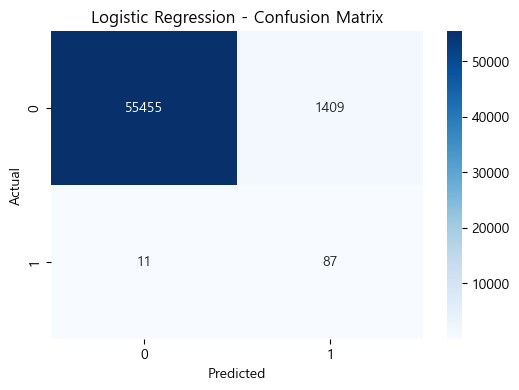


=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.41      0.78      0.54        98

    accuracy                           1.00     56962
   macro avg       0.71      0.89      0.77     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.8868


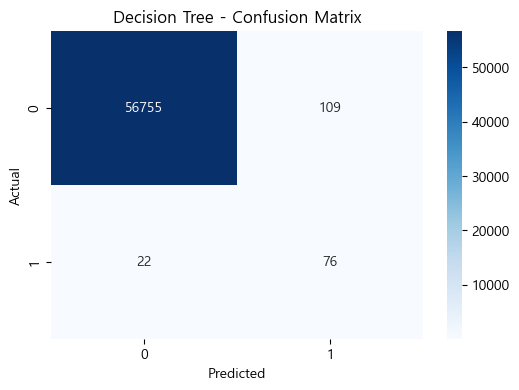


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9673


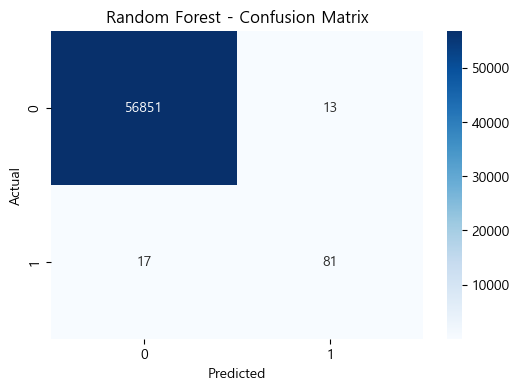


=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.81      0.64        98

    accuracy                           1.00     56962
   macro avg       0.76      0.90      0.82     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9563


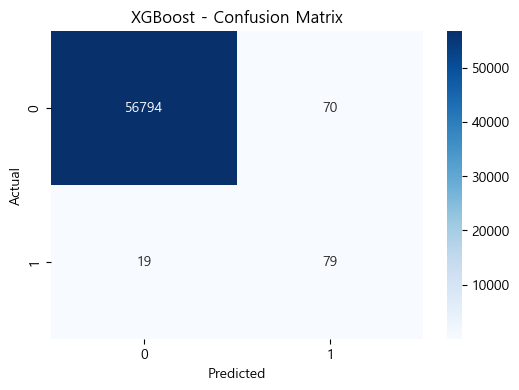

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== LightGBM ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.58      0.82      0.68        98

    accuracy                           1.00     56962
   macro avg       0.79      0.91      0.84     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9636


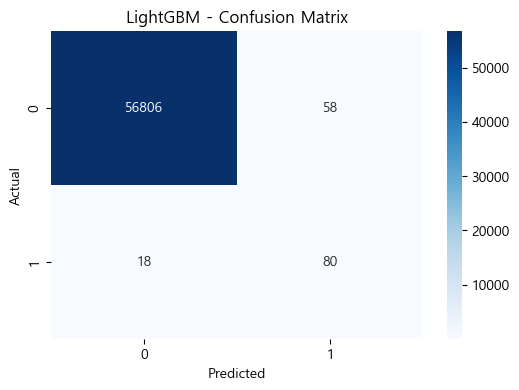

In [7]:
# 4. 모델 학습 및 평가
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 평가 함수
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # 학습
    model.fit(X_train, y_train)
    
    # 예측
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 평가 지표
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return y_pred_proba

# 모델 정의
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), 
                             random_state=42),
    'LightGBM': LGBMClassifier(class_weight='balanced', random_state=42),
}

# 각 모델 학습 및 평가
results = {}
for name, model in models.items():
    proba = evaluate_model(model, X_train_smote, y_train_smote, X_test, y_test, name)
    results[name] = proba

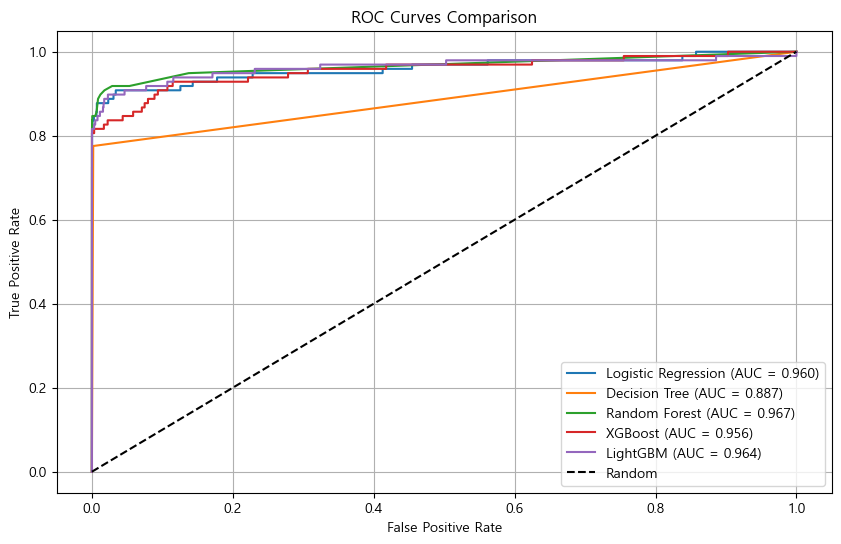

In [10]:
# 5. ROC Curve 비교
plt.figure(figsize=(10, 6))
for name, y_pred_proba in results.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
############################################################################
# 6. 하이퍼파라미터 튜닝 => 810m 걸렸는데 못 끝냄.. 실행시 조심!!!!!
############################################################################
from sklearn.model_selection import GridSearchCV

# Random Forest 예시
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train_smote, y_train_smote)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")

# 최적 모델로 평가
best_model = grid_search.best_estimator_
evaluate_model(best_model, X_train_smote, y_train_smote, X_test, y_test, "Tuned Random Forest")

In [ ]:
# 1. 기본 앙상블 - Voting Classifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 다양한 특성을 가진 모델 조합
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
        ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
        ('xgb', XGBClassifier(scale_pos_weight=100, random_state=42)),
        ('lgbm', LGBMClassifier(class_weight='balanced', random_state=42))
    ],
    voting='soft'  # 확률 기반 투표
)

voting_clf.fit(X_train_smote, y_train_smote)
y_pred = voting_clf.predict(X_test)
y_pred_proba = voting_clf.predict_proba(X_test)[:, 1]

print(f"Voting Ensemble ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

In [8]:
# 2. Stacking Classifier (추천!)
from sklearn.ensemble import StackingClassifier

# Base models (다양성 확보)
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced', random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=100, random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# Meta model
meta_model = LogisticRegression(class_weight='balanced')

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

stacking_clf.fit(X_train_smote, y_train_smote)
y_pred_proba = stacking_clf.predict_proba(X_test)[:, 1]

print(f"Stacking Ensemble ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034638 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 181961, number of negative: 181960
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 363921, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 181960, number of negativ

In [ ]:
# 3. 가중치 기반 앙상블 (커스텀)
# 개별 모델 학습
models = {
    'rf': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'xgb': XGBClassifier(n_estimators=200, scale_pos_weight=100, random_state=42),
    'lgbm': LGBMClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'catboost': CatBoostClassifier(iterations=200, class_weights=[1, 100], verbose=0, random_state=42)
}

predictions = {}
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    predictions[name] = model.predict_proba(X_test)[:, 1]
    print(f"{name} ROC-AUC: {roc_auc_score(y_test, predictions[name]):.4f}")

# 가중 평균 (성능 기반 가중치)
weights = {
    'rf': 0.2,
    'xgb': 0.3,
    'lgbm': 0.3,
    'catboost': 0.2
}

weighted_pred = sum(predictions[name] * weight for name, weight in weights.items())
print(f"\nWeighted Ensemble ROC-AUC: {roc_auc_score(y_test, weighted_pred):.4f}")

In [ ]:
# 4. 추천 조합별 특징 - 이후 3개 셀은 실행시키지 마세요~
# 조합 A: 균형잡힌 앙상블
estimators = [
    ('lr', LogisticRegression(class_weight='balanced')),  # 선형 모델
    ('rf', RandomForestClassifier(class_weight='balanced')),  # 배깅
    ('xgb', XGBClassifier(scale_pos_weight=100)),  # 부스팅
    ('svm', SVC(probability=True, class_weight='balanced'))  # 커널 기반
]
# 장점: 다양한 알고리즘 특성 활용
# 단점: SVM은 느림

In [ ]:
# 조합 B: 트리 기반 앙상블 (추천!)
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced')),
    ('xgb', XGBClassifier(n_estimators=200, scale_pos_weight=100)),
    ('lgbm', LGBMClassifier(n_estimators=200, class_weight='balanced')),
    ('catboost', CatBoostClassifier(iterations=200, class_weights=[1, 100], verbose=0))
]
# 장점: 모두 트리 기반이지만 다른 방식 (배깅 vs 부스팅)
# 추천 이유: 빠르고 성능 우수

In [ ]:
# 조합 C: 부스팅 앙상블
estimators = [
    ('xgb', XGBClassifier(scale_pos_weight=100)),
    ('lgbm', LGBMClassifier(class_weight='balanced')),
    ('catboost', CatBoostClassifier(class_weights=[1, 100], verbose=0)),
    ('gb', GradientBoostingClassifier())
]
# 장점: 모두 강력한 부스팅 알고리즘
# 단점: 과적합 가능성

In [ ]:
# 5. 최적 가중치 찾기
from scipy.optimize import minimize

def objective(weights, predictions, y_true):
    weighted_pred = sum(pred * w for pred, w in zip(predictions.values(), weights))
    return -roc_auc_score(y_true, weighted_pred)  # 음수 (최소화)

# 초기 가중치
initial_weights = [0.25] * len(predictions)

# 제약 조건: 가중치 합 = 1
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * len(predictions)

result = minimize(
    objective,
    initial_weights,
    args=(predictions, y_test),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x
print("Optimal weights:", dict(zip(predictions.keys(), optimal_weights)))

optimal_pred = sum(pred * w for pred, w in zip(predictions.values(), optimal_weights))
print(f"Optimized Ensemble ROC-AUC: {roc_auc_score(y_test, optimal_pred):.4f}")

In [ ]:
# 6. 전체 파이프라인 예시
from sklearn.pipeline import Pipeline

# Stacking with preprocessing
stacking_pipeline = Pipeline([
    ('stacking', StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=200, max_depth=20, 
                                         class_weight='balanced', random_state=42)),
            ('xgb', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                 scale_pos_weight=100, random_state=42)),
            ('lgbm', LGBMClassifier(n_estimators=200, num_leaves=31,
                                   class_weight='balanced', random_state=42))
        ],
        final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
        cv=5
    ))
])

stacking_pipeline.fit(X_train_smote, y_train_smote)
y_pred_proba = stacking_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, (y_pred_proba > 0.5).astype(int)))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

In [ ]:
# 7. 성능 비교 함수
def compare_ensembles(X_train, y_train, X_test, y_test):
    results = {}
    
    # 1. Voting
    voting = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(class_weight='balanced', random_state=42)),
            ('xgb', XGBClassifier(scale_pos_weight=100, random_state=42)),
            ('lgbm', LGBMClassifier(class_weight='balanced', random_state=42))
        ],
        voting='soft'
    )
    voting.fit(X_train, y_train)
    results['Voting'] = roc_auc_score(y_test, voting.predict_proba(X_test)[:, 1])
    
    # 2. Stacking
    stacking = StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(class_weight='balanced', random_state=42)),
            ('xgb', XGBClassifier(scale_pos_weight=100, random_state=42)),
            ('lgbm', LGBMClassifier(class_weight='balanced', random_state=42))
        ],
        final_estimator=LogisticRegression(class_weight='balanced')
    )
    stacking.fit(X_train, y_train)
    results['Stacking'] = roc_auc_score(y_test, stacking.predict_proba(X_test)[:, 1])
    
    return pd.DataFrame(results, index=['ROC-AUC']).T.sort_values('ROC-AUC', ascending=False)

comparison = compare_ensembles(X_train_smote, y_train_smote, X_test, y_test)
print(comparison)